In [7]:
from pathlib import Path
import time
import random

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import load_model

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_HEIGHT = 256
IMG_WIDTH = 256
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

UNET_PATH = ROOT / "model" / "unet_flood_model_final.h5"
ATTENTION_PATH = ROOT / "model" / "attention_unet_flood.h5"

# Ganti dengan lokasi gambar uji Anda
TEST_IMAGE_PATH = str(ROOT / "img" / "pic1.png")

print("Konfigurasi siap.")

Konfigurasi siap.


In [2]:
def preprocess_image(path):
    path = Path(path)
    image = cv2.imread(str(path))
    if image is None:
        raise ValueError(f"Gambar tidak dapat dibaca: {path}")
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(
        image_rgb,
        (IMG_WIDTH, IMG_HEIGHT),
        interpolation=cv2.INTER_AREA,
    )
    normalized = resized.astype(np.float32) / 255.0
    return image_rgb, np.expand_dims(normalized, axis=0)


def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true = K.flatten(y_true)
    y_pred = K.flatten(y_pred)
    intersection = K.sum(y_true * y_pred)
    return (2.0 * intersection + smooth) / (
        K.sum(y_true) + K.sum(y_pred) + smooth
    )


def postprocess_mask(prediction, threshold=0.5):
    mask = prediction[0, :, :, 0]
    return (mask > threshold).astype(np.uint8) * 255


def calculate_prediction_metrics(prediction):
    mask = prediction[0, :, :, 0]
    binary_mask = mask > 0.5
    flood_pixels = int(binary_mask.sum())
    return {
        "flood_percentage": float(binary_mask.mean() * 100),
        "confidence": float(mask[binary_mask].mean() * 100)
        if flood_pixels else 0.0,
    }

print("Preprocessing siap.")

Preprocessing siap.


In [3]:
def load_model_checked(path):
    if not path.exists():
        raise FileNotFoundError(f"Model tidak ditemukan: {path}")
    return load_model(
        str(path),
        custom_objects={"dice_coef": dice_coef},
        compile=False,
    )

models = {
    "U-Net": load_model_checked(UNET_PATH),
    "Attention U-Net": load_model_checked(ATTENTION_PATH),
}
print("Dua model berhasil dimuat.")

Dua model berhasil dimuat.


In [8]:
if not TEST_IMAGE_PATH:
    print("Isi TEST_IMAGE_PATH dengan lokasi gambar uji terlebih dahulu.")
else:
    original_image, input_tensor = preprocess_image(TEST_IMAGE_PATH)
    results = {}

    for name, model in models.items():
        start_time = time.perf_counter()
        prediction = model.predict(input_tensor, verbose=0)
        elapsed = time.perf_counter() - start_time
        results[name] = {
            "prediction": prediction,
            "mask": postprocess_mask(prediction),
            "inference_seconds": elapsed,
            **calculate_prediction_metrics(prediction),
        }

    print(f"Input model: {input_tensor.shape}, {input_tensor.dtype}")
    for name, result in results.items():
        print(f"{name}: {result['inference_seconds']:.4f} detik")

Input model: (1, 256, 256, 3), float32
U-Net: 1.6154 detik
Attention U-Net: 1.2565 detik


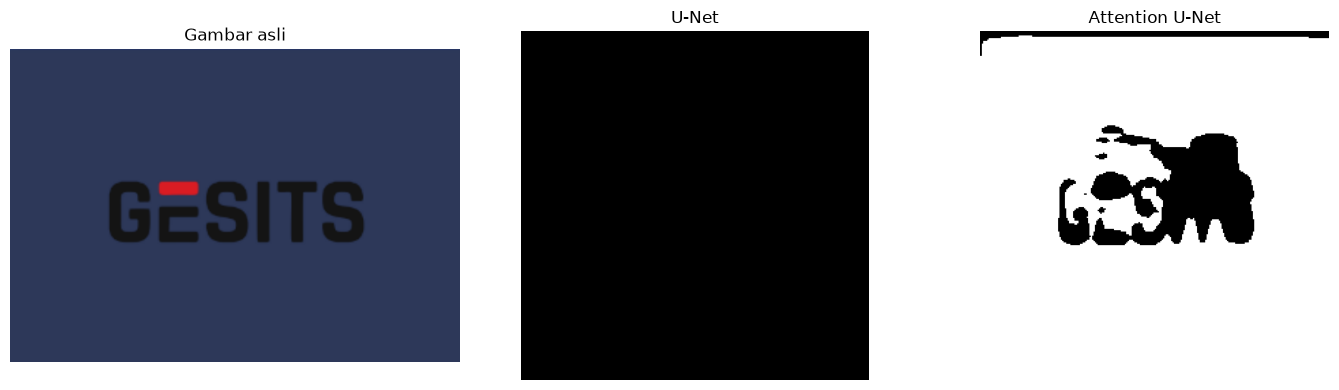

In [9]:
if TEST_IMAGE_PATH:
    figure, axes = plt.subplots(1, len(results) + 1, figsize=(14, 4))
    axes[0].imshow(original_image)
    axes[0].set_title("Gambar asli")
    axes[0].axis("off")

    for axis, (name, result) in zip(axes[1:], results.items()):
        axis.imshow(result["mask"], cmap="gray")
        axis.set_title(name)
        axis.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("Visualisasi menunggu TEST_IMAGE_PATH diisi.")

In [10]:
if TEST_IMAGE_PATH:
    rows = []
    model_paths = {
        "U-Net": UNET_PATH,
        "Attention U-Net": ATTENTION_PATH,
    }

    for name, result in results.items():
        rows.append({
            "model": name,
            "model_size_mb": round(
                model_paths[name].stat().st_size / (1024 ** 2), 2
            ),
            "parameters": models[name].count_params(),
            "inference_seconds": round(result["inference_seconds"], 4),
            "flood_percentage": round(result["flood_percentage"], 2),
            "confidence": round(result["confidence"], 2),
        })

    comparison_df = pd.DataFrame(rows)
    display(comparison_df)
else:
    print("Tabel perbandingan menunggu TEST_IMAGE_PATH diisi.")

# Dice dan IoU hanya dapat dihitung jika ground truth mask tersedia.

,model,model_size_mb,parameters,inference_seconds,flood_percentage,confidence
0,U-Net,89.19,7782913,1.6154,0.00,0.00
1,Attention U-Net,81.86,7138020,1.2565,87.99,79.38
